# M046 Reports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.append("../../")

import pyaldata as pyal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from tools.reports.report_initial import run_initial_report
from tools.params import Params, colors
from tools.dsp.preprocessing import preprocess
import tools.viz.mean_firing as firing
import tools.viz.dimensionality as dim
import tools.viz.utilityTools as vizutils
import tools.decoding.rrr as rrr
import tools.decoding.decodeTools as decutils
import tools.dataTools as dt




## 18th Dec. 16:00h

In [2]:
# Files 
session = 'M046_2024_12_18_16_00'
data_dir = f"/data/bnd-data/raw/M046/{session}"

areas=["MOp", "SSp", "CP", "VAL"]
df = pyal.load_pyaldata(data_dir)
df_ = preprocess(df, only_trials=False, repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y'])

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extend

/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assum

Combined every 3 bins
Resulting VAL_spikes ephys data shape is (NxT): (202, 10000)
Resulting SSp_spikes ephys data shape is (NxT): (105, 10000)
Resulting all_spikes ephys data shape is (NxT): (12, 10000)
Resulting MOp_spikes ephys data shape is (NxT): (182, 10000)
Resulting CP_spikes ephys data shape is (NxT): (252, 10000)


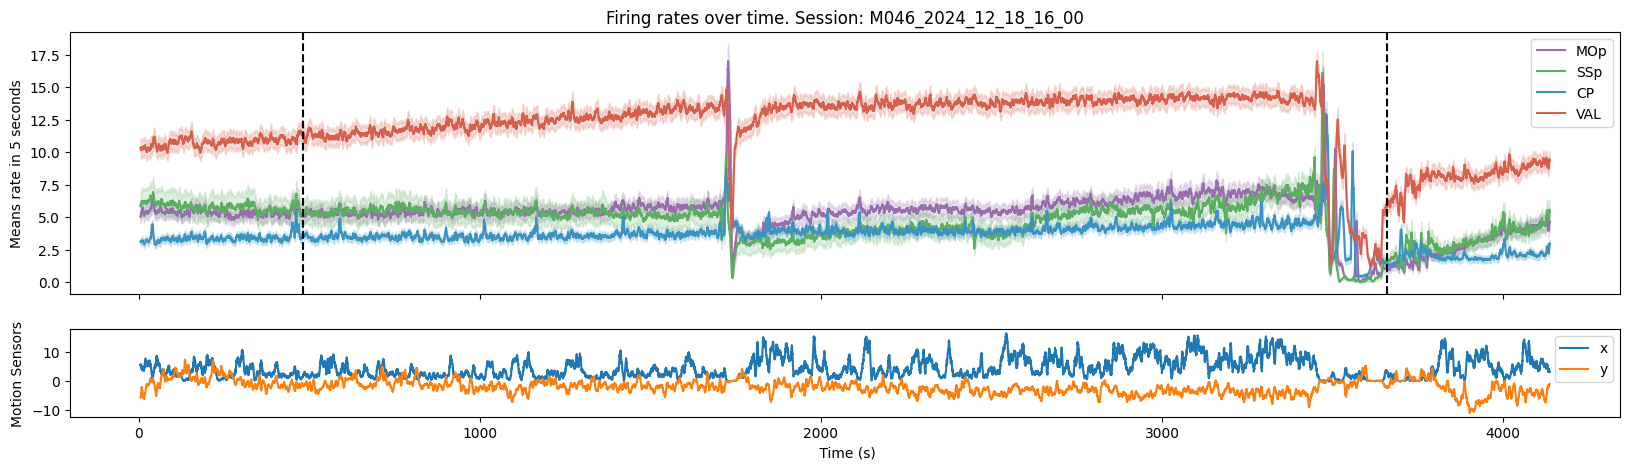

In [3]:
from scipy import stats
from tools import params
from tools.dsp.utils import moving_window_mean
from tools.viz.utilityTools import shaded_errorbar

window = 5  # in seconds

fig, ax = plt.subplots(2, 1, figsize=(20, 5), sharex='all', gridspec_kw={'height_ratios': [3, 1]})
areas=["MOp", "SSp", "CP", "VAL"]


for area in areas:
    all_rates = np.concatenate(df_[f"{area}_rates"].values, axis=0)
    means, time_bins = moving_window_mean(all_rates, int(window / Params.BIN_SIZE))
    shaded_errorbar(ax[0], x=time_bins * Params.BIN_SIZE, y=means, errorStat=stats.sem, 
                    color=getattr(params.colors, f"{area}_light", "k"),
                    label=area
                    )
    
all_motion_sensor_x = np.concatenate(df_[f"values_MotSen1_X"].values, axis=0)
all_motion_sensor_y = np.concatenate(df_[f"values_MotSen1_Y"].values, axis=0)

motion_sensor_means_x, _ = moving_window_mean(all_motion_sensor_x, int(window / Params.BIN_SIZE))
motion_sensor_means_y, _ = moving_window_mean(all_motion_sensor_y, int(window / Params.BIN_SIZE))

ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_x, label='x')
ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_y, label='y')
ax[1].set_ylabel(f'Motion Sensors')
ax[1].legend()


ax[0].set_ylabel(f'Means rate in {window} seconds')
ax[1].set_xlabel(f' Time (s)')
ax[0].axvline(x=480, color="k", linestyle="--")
ax[0].axvline(x=3660, color="k", linestyle="--")
ax[0].set_title(f'Firing rates over time. Session: {session}')
ax[0].legend()


## 19th Decemeber

In [4]:
# Files 
session = 'M046_2024_12_19_13_30'
data_dir = f"/data/bnd-data/raw/M046/{session}"

areas=["MOp", "SSp", "CP", "VAL"]
df = pyal.load_pyaldata(data_dir)
df_ = preprocess(df, only_trials=False, repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y'])

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extend

/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assum

Combined every 3 bins
Resulting VAL_spikes ephys data shape is (NxT): (176, 10000)
Resulting all_spikes ephys data shape is (NxT): (15, 10000)
Resulting SSp_spikes ephys data shape is (NxT): (138, 10000)
Resulting MOp_spikes ephys data shape is (NxT): (169, 10000)
Resulting CP_spikes ephys data shape is (NxT): (276, 10000)


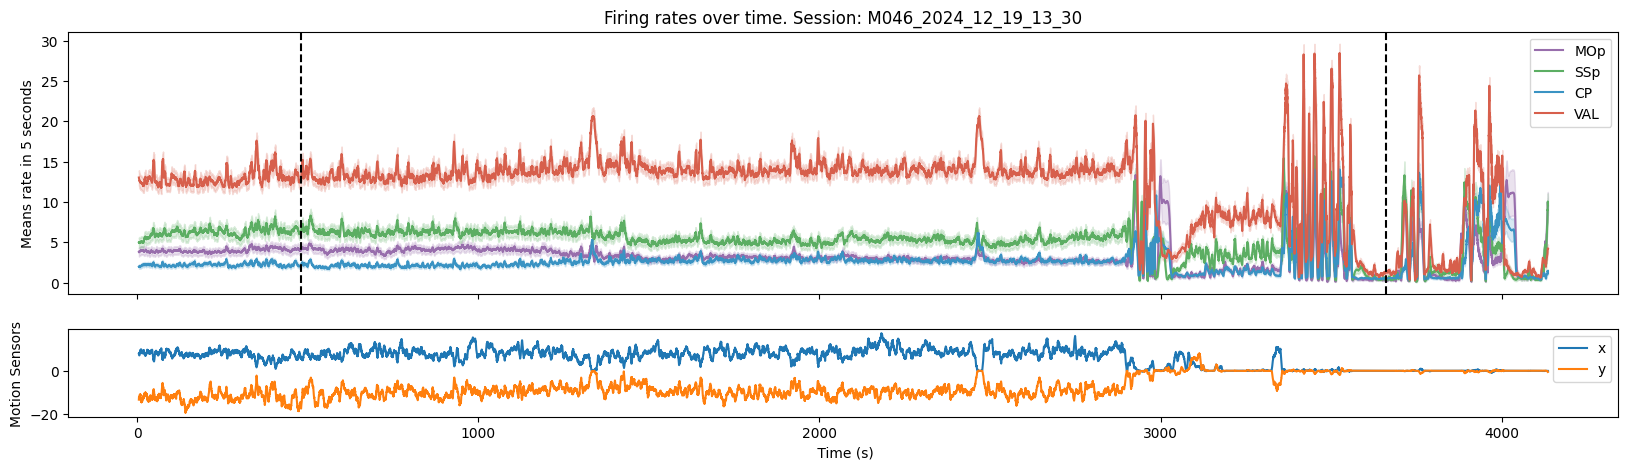

In [5]:
from scipy import stats
from tools import params
from tools.dsp.utils import moving_window_mean
from tools.viz.utilityTools import shaded_errorbar

window = 5  # in seconds

fig, ax = plt.subplots(2, 1, figsize=(20, 5), sharex='all', gridspec_kw={'height_ratios': [3, 1]})
areas=["MOp", "SSp", "CP", "VAL"]


for area in areas:
    all_rates = np.concatenate(df_[f"{area}_rates"].values, axis=0)
    means, time_bins = moving_window_mean(all_rates, int(window / Params.BIN_SIZE))
    shaded_errorbar(ax[0], x=time_bins * Params.BIN_SIZE, y=means, errorStat=stats.sem, 
                    color=getattr(params.colors, f"{area}_light", "k"),
                    label=area
                    )
    
all_motion_sensor_x = np.concatenate(df_[f"values_MotSen1_X"].values, axis=0)
all_motion_sensor_y = np.concatenate(df_[f"values_MotSen1_Y"].values, axis=0)

motion_sensor_means_x, _ = moving_window_mean(all_motion_sensor_x, int(window / Params.BIN_SIZE))
motion_sensor_means_y, _ = moving_window_mean(all_motion_sensor_y, int(window / Params.BIN_SIZE))

ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_x, label='x')
ax[1].plot(time_bins * Params.BIN_SIZE, motion_sensor_means_y, label='y')
ax[1].set_ylabel(f'Motion Sensors')
ax[1].legend()


ax[0].set_ylabel(f'Means rate in {window} seconds')
ax[1].set_xlabel(f' Time (s)')
ax[0].axvline(x=480, color="k", linestyle="--")
ax[0].axvline(x=3660, color="k", linestyle="--")
ax[0].set_title(f'Firing rates over time. Session: {session}')
ax[0].legend()


## Report

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field SSp_ll_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field SSp_ll_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.


/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: motion_sensor_xy might be a time-varying field. It matches the length of Thal_spikes on 99.87562189054727% of trials
  warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyalda

Combined every 3 bins
Resulting Thal_spikes ephys data shape is (NxT): (202, 10000)
Resulting SSp_ll_spikes ephys data shape is (NxT): (105, 10000)
Resulting all_spikes ephys data shape is (NxT): (12, 10000)
Resulting MOp_spikes ephys data shape is (NxT): (182, 10000)
Resulting CP_spikes ephys data shape is (NxT): (252, 10000)
200


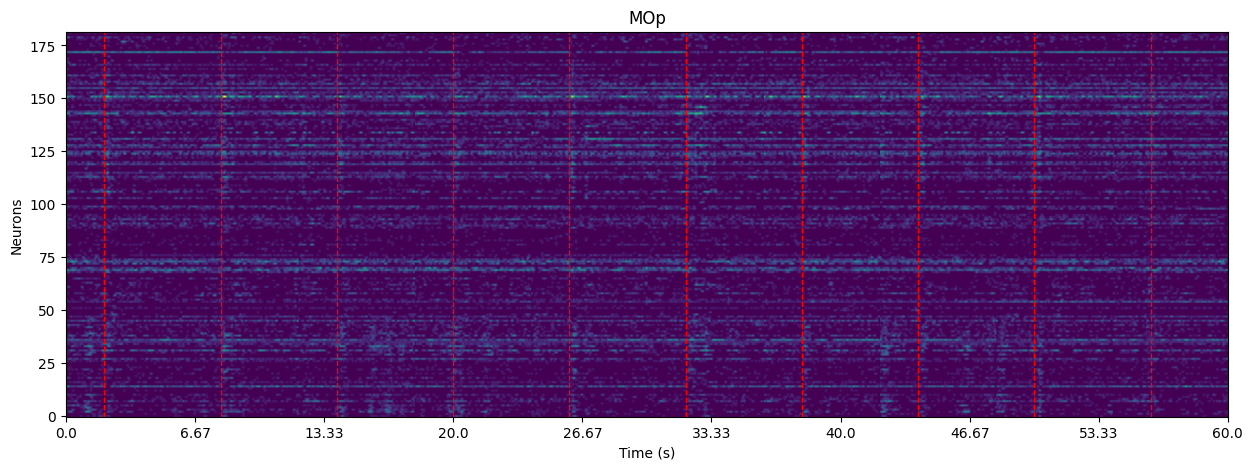

200


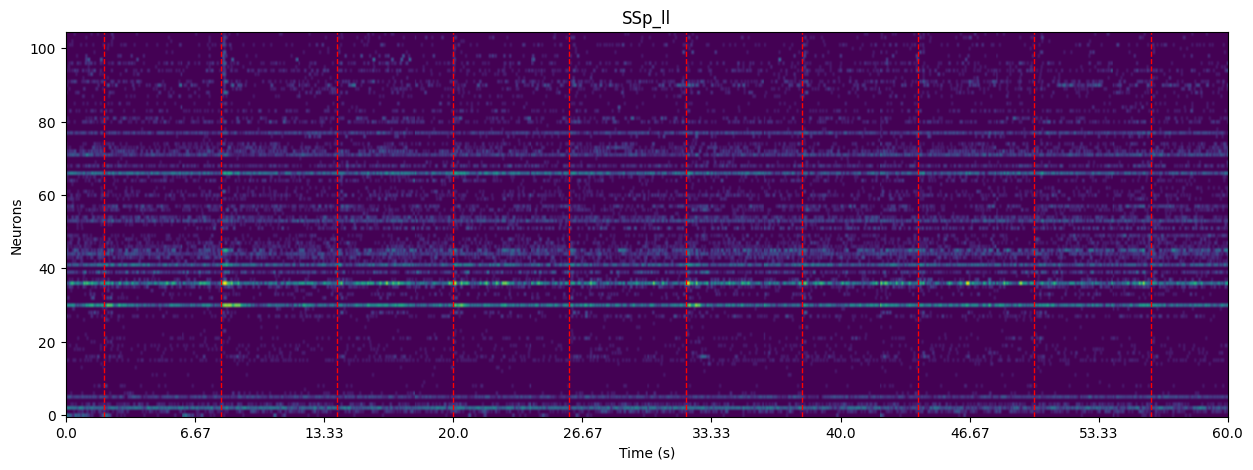

200


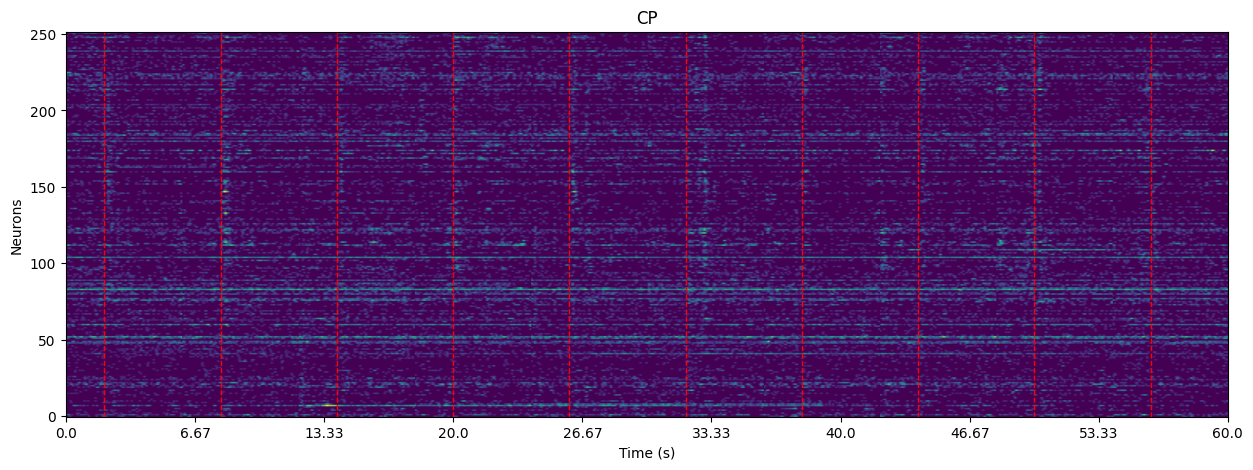

200


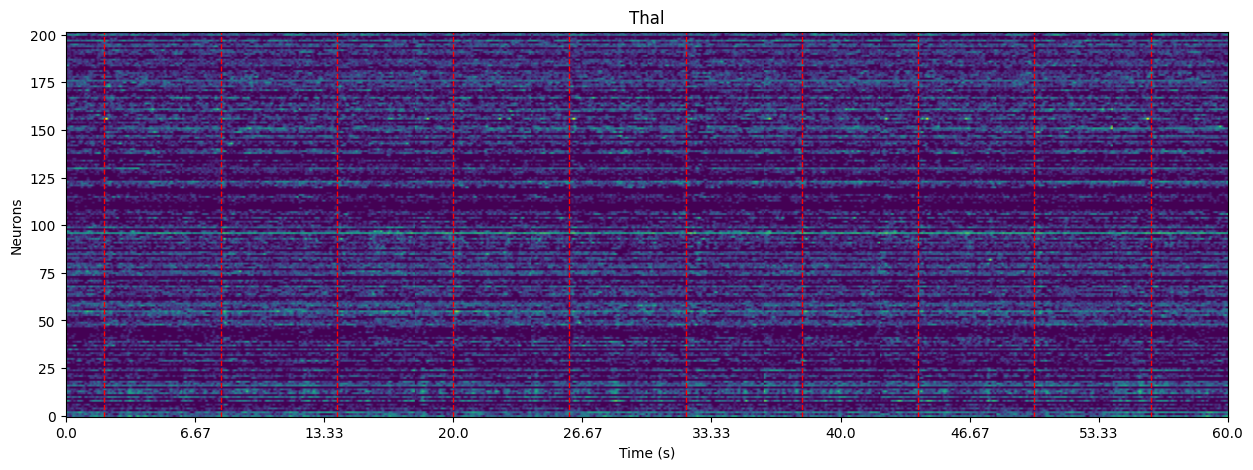

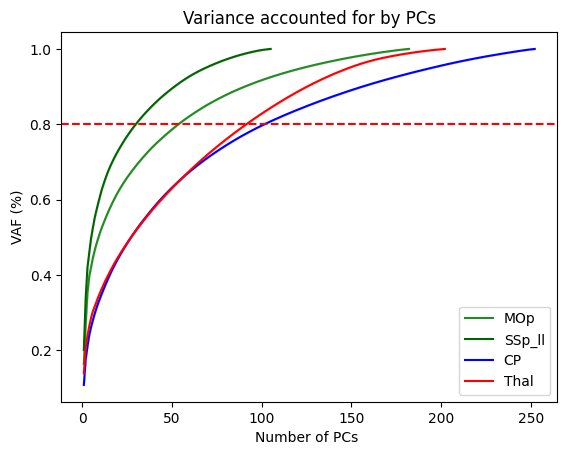

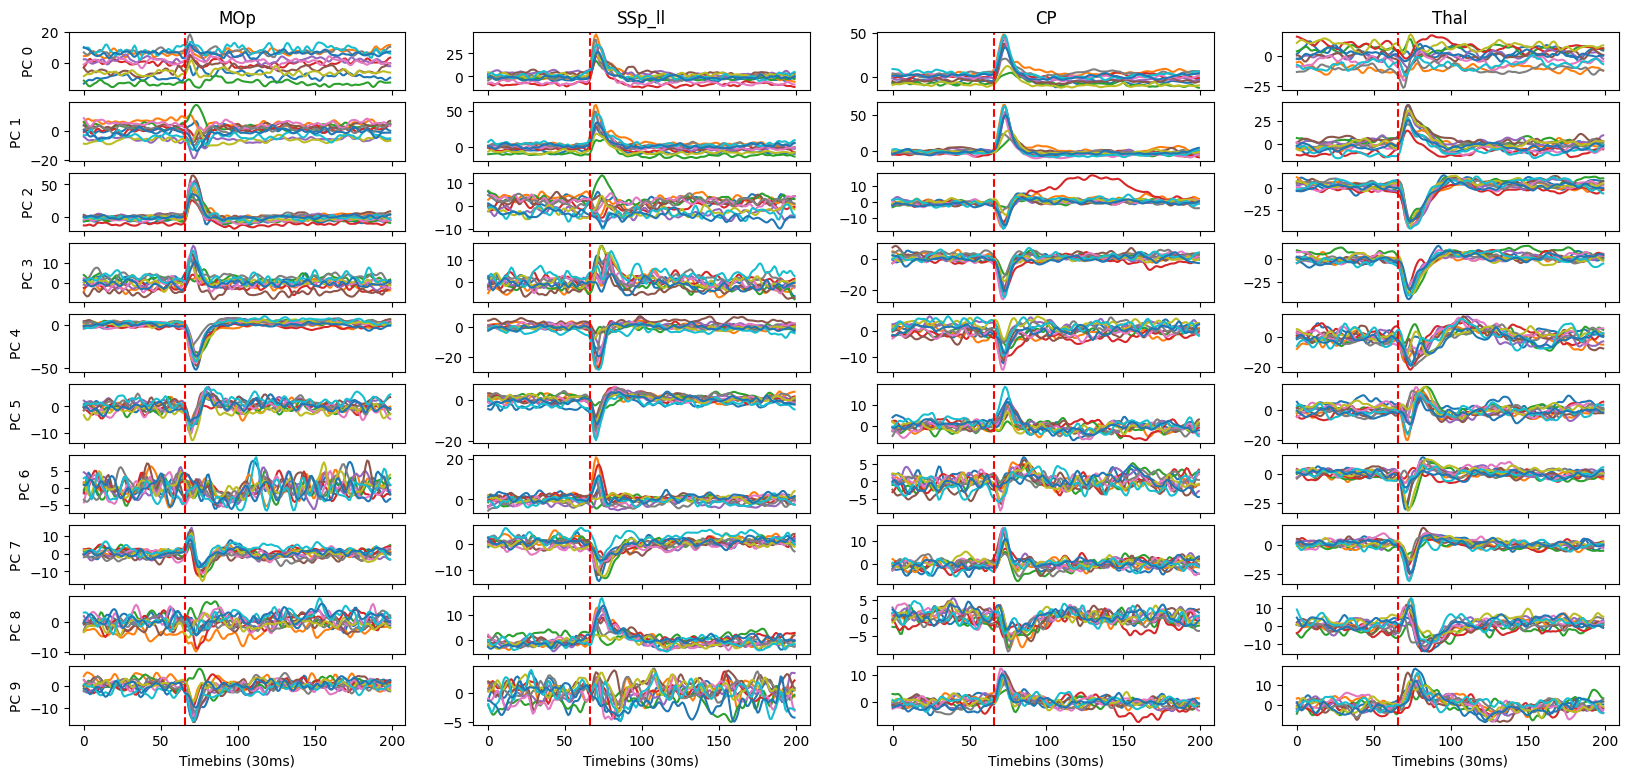

In [2]:
# Files 
data_dir = "/data/bnd-data/raw/M046/M046_2024_12_18_16_00"
fname0 = os.path.join(data_dir, "M046_2024_12_18_16_00_pyaldata_0.mat")
fname1 = os.path.join(data_dir, "M046_2024_12_18_16_00_pyaldata_1.mat")

# Load files
df0 = pyal.mat2dataframe(fname0, shift_idx_fields=False)
df1 = pyal.mat2dataframe(fname1, shift_idx_fields=False)
df = pd.concat([df0, df1], ignore_index=True)

run_initial_report(df, areas=["MOp", "SSp_ll", "CP", "Thal"])

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field SSp_ll_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field SSp_ll_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.


/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: motion_sensor_xy might be a time-varying field. It matches the length of Thal_spikes on 99.87562189054727% of trials
  warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyalda

Combined every 3 bins
Resulting Thal_spikes ephys data shape is (NxT): (202, 10000)
Resulting SSp_ll_spikes ephys data shape is (NxT): (105, 10000)
Resulting all_spikes ephys data shape is (NxT): (12, 10000)
Resulting MOp_spikes ephys data shape is (NxT): (182, 10000)
Resulting CP_spikes ephys data shape is (NxT): (252, 10000)
200


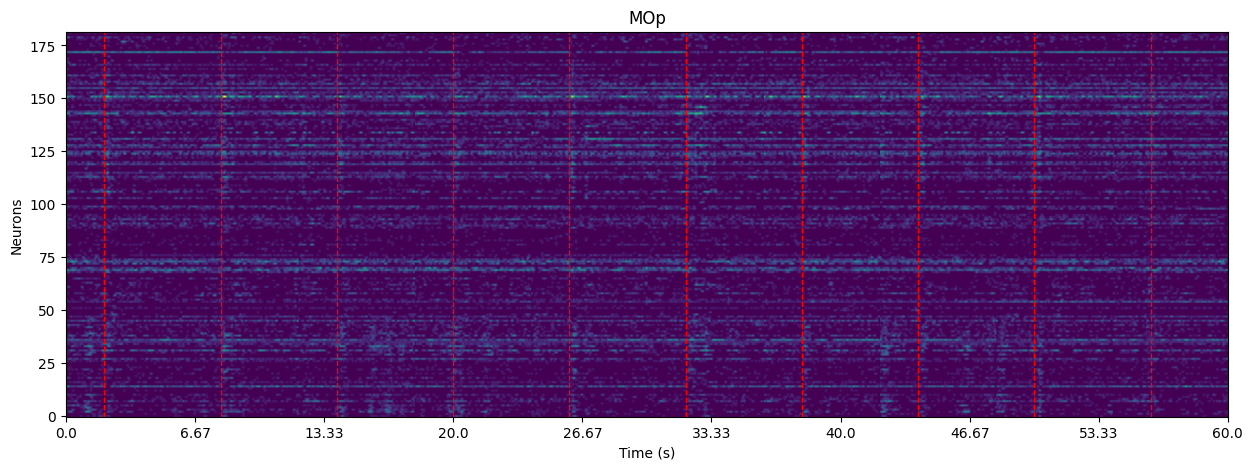

200


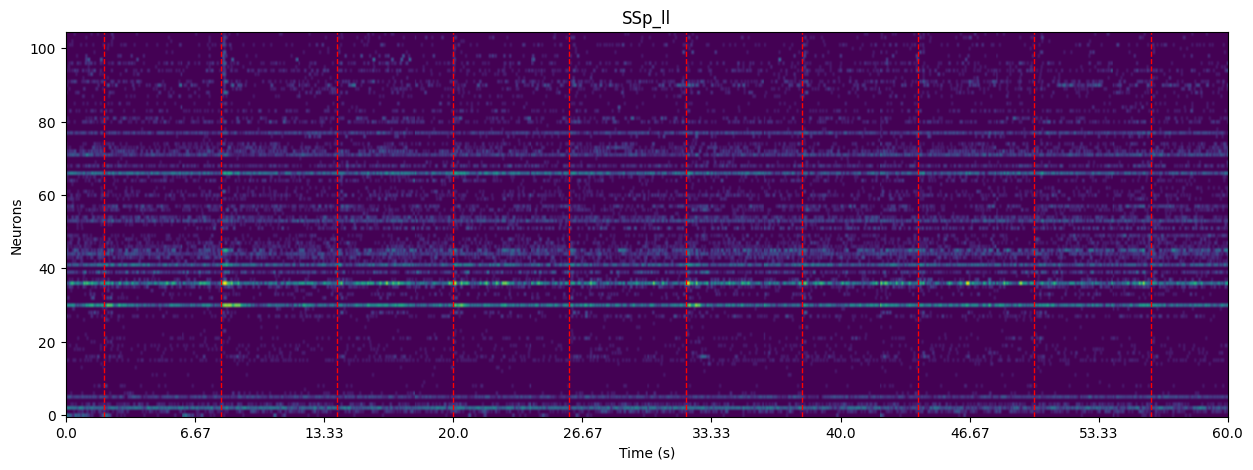

200


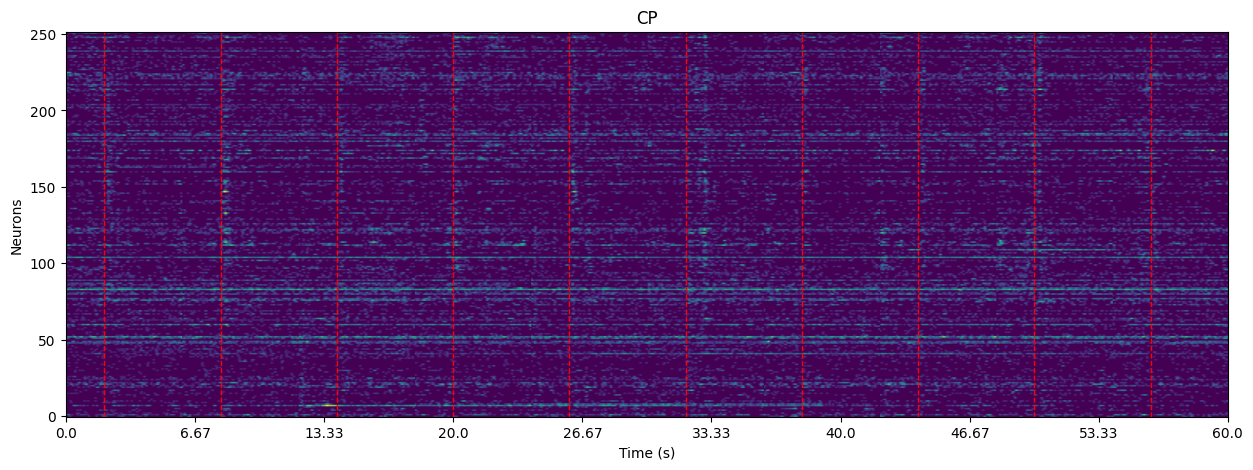

200


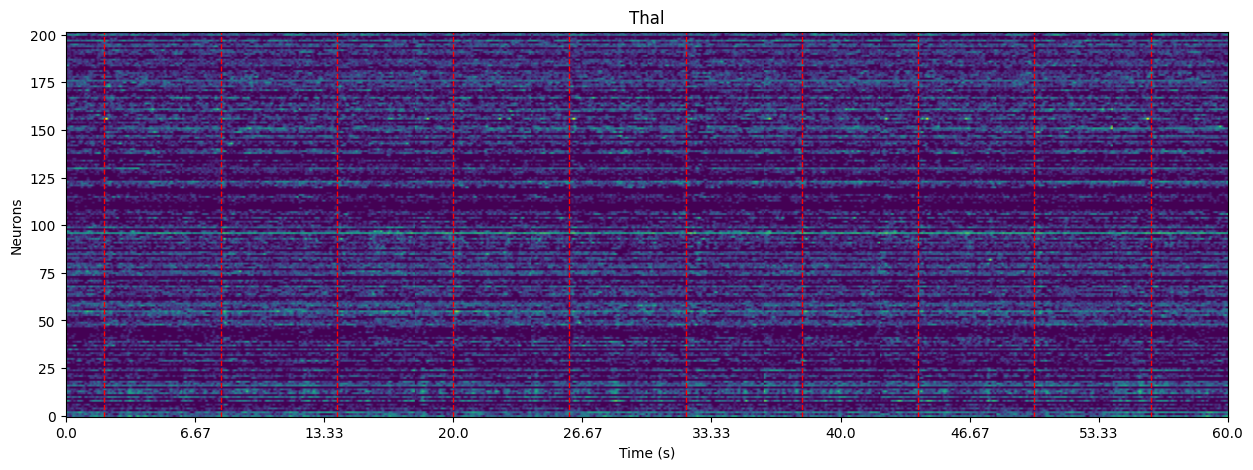

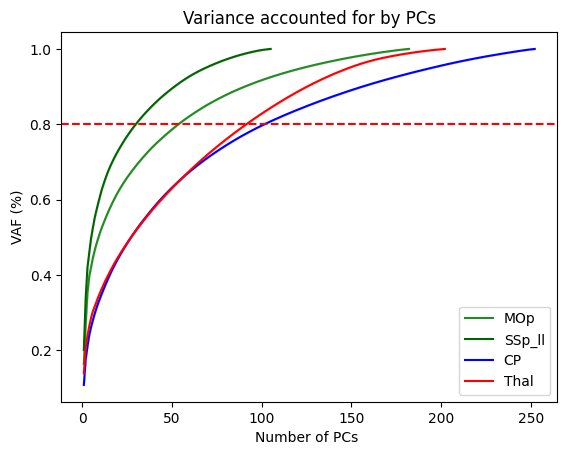

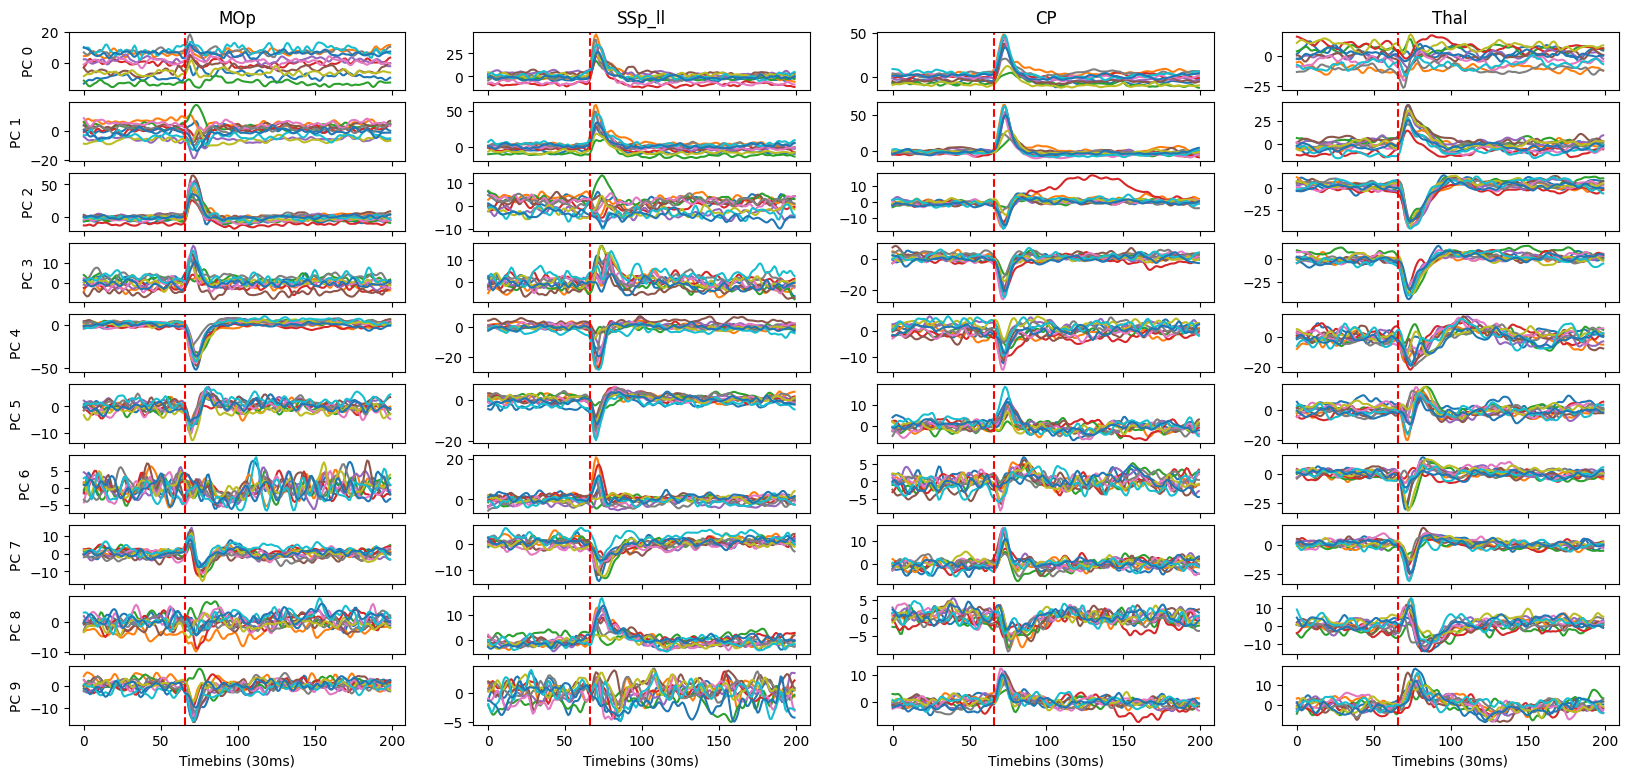

In [3]:
# Files 
data_dir = "/data/bnd-data/raw/M046/M046_2024_12_18_16_00"
fname0 = os.path.join(data_dir, "M046_2024_12_18_16_00_pyaldata_0.mat")
fname1 = os.path.join(data_dir, "M046_2024_12_18_16_00_pyaldata_1.mat")

# Load files
df0 = pyal.mat2dataframe(fname0, shift_idx_fields=False)
df1 = pyal.mat2dataframe(fname1, shift_idx_fields=False)
df = pd.concat([df0, df1], ignore_index=True)

run_initial_report(df, areas=["MOp", "SSp_ll", "CP", "Thal"])